https://www.nature.com/articles/s41467-017-02608-8

https://static-content.springer.com/esm/art%3A10.1038%2Fs41467-017-02608-8/MediaObjects/41467_2017_2608_MOESM1_ESM.pdf  

https://journals.aps.org/prapplied/pdf/10.1103/PhysRevApplied.12.044051

https://github.com/kpobrien/JosephsonCircuits.jl

# JTWPA Zorin style

Simulations of the linearized system can be effectively parallelized, so we suggest starting Julia with the number of threads equal to the number of physical cores. See the Julia documentation for the procedure.

In [1]:
Threads.nthreads()

1

From "Flux-Driven Josephson Traveling-Wave Parametric Amplifier" (2019) A.B. Zorin

In [2]:
using JosephsonCircuits
using Plots

In [3]:
const magnetic_flux_quantum = 2.0678338484619295e-15
const reduced_magnetic_flux_quantum = magnetic_flux_quantum / (2*pi)

@variables Rport C Cj Lj Lpump Cpump kappa Lg Lsmall

# From Section V. POSSIBLE CIRCUIT DESIGN
cutoff_frequency = 46e9 # [Hz]
transmission_line_impedance = 50.0

capacitance = 1 / (2 * pi * cutoff_frequency * transmission_line_impedance) # equation (51) [H]
junction_inductance = transmission_line_impedance / (2 * pi * cutoff_frequency) # L = L', equation (52) [F]
critical_current = reduced_magnetic_flux_quantum / junction_inductance

critical_current_density = 3e6 # Typical value mentioned in paper [A/m^2]
jj_area = critical_current / critical_current_density # [m^2]
jj_cap_density = 50 * 1e-15 / (1e-6)^2 # Typical [F/m^2]
jj_capacitance = jj_cap_density * jj_area

nr_cells = 500
modulation_parameter = 0.06

coupling = 0.02 # = M / L', equation (8)
mutual_inductance = coupling * junction_inductance
# Add small linear inductance in dc-SQUID loop to couple pump line inductance with
linear_squid_loop_inductance = mutual_inductance^2 / junction_inductance

# in order to reduce critical current of dc squid to critical current of junction
optimal_dc_flux = magnetic_flux_quantum / 3
Idc = optimal_dc_flux / mutual_inductance
Ip = modulation_parameter * Idc                 #pump current

pump_line_inductance = 1.1 * junction_inductance

pump_frequency = 20e9 # [Hz]
frequency_detuning = range(-0.5, 1.5, 500)
signal_frequency = pump_frequency / 2 .* (frequency_detuning .+ 1)

5.0e9:4.008016032064128e7:2.5e10

In [4]:
circuit = Tuple{String,String,String,Num}[]
entry = (elem, n1, n2, value) -> push!(circuit, ("$(elem)$(n1)_$(n2)", "$n1", "$n2", value))

function build_circuit()
    node = 1

    node_p1 = node # P1: Start of transmission line
    entry("P", node_p1, 0, 1)
    entry("R", node_p1, 0, Rport)

    node_p3 = node+1 # P3: Start of pump line
    entry("P", node_p3, 0, 3)
    entry("R", node_p3, 0, Rport)

    for cell_index in 1:nr_cells
        if cell_index == 1
            entry("C", node, 0, C/2)
        else
            entry("C", node, 0, C)
        end
        entry("Lj_a", node, node+3, Lj)
        entry("Cj_a", node, node+3, Cj)
        entry("L", node, node+2, Lsmall)
        entry("Lj_b", node+2, node+3, Lj)
        entry("Cj_b", node+2, node+3, Cj)

        entry("L", node+1, node+4, Lpump)
        if cell_index == 1
            entry("C", node+1, 0, Cpump/2)
        else
            entry("C", node+1, 0, Cpump)
        end
        push!(circuit, ("K$(node)", "L$(node)_$(node+2)", "L$(node+1)_$(node+4)", kappa))

        node += 3
    end

    entry("C", node, 0, C/2)
    entry("P", node, 0, 2) # P2: End of transmission line
    entry("R", node, 0, Rport)

    entry("C", node+1, 0, Cpump/2)
    entry("P", node+1, 0, 4) # P4: End of pump line
    entry("R", node+1, 0, Rport)
    entry("L", node+1, 0, Lg)

end

build_circuit()

4511-element Vector{Tuple{String, String, String, Num}}:
 ("P1_0", "1", "0", 1)
 ("R1_0", "1", "0", Rport)
 ("P2_0", "2", "0", 3)
 ("R2_0", "2", "0", Rport)
 ("C1_0", "1", "0", (1//2)*C)
 ("Lj_a1_4", "1", "4", Lj)
 ("Cj_a1_4", "1", "4", Cj)
 ("L1_3", "1", "3", Lsmall)
 ("Lj_b3_4", "3", "4", Lj)
 ("Cj_b3_4", "3", "4", Cj)
 ("L2_5", "2", "5", Lpump)
 ("C2_0", "2", "0", (1//2)*Cpump)
 ("K1", "L1_3", "L2_5", kappa)
 ⋮
 ("Lj_b1500_1501", "1500", "1501", Lj)
 ("Cj_b1500_1501", "1500", "1501", Cj)
 ("L1499_1502", "1499", "1502", Lpump)
 ("C1499_0", "1499", "0", Cpump)
 ("K1498", "L1498_1500", "L1499_1502", kappa)
 ("C1501_0", "1501", "0", (1//2)*C)
 ("P1501_0", "1501", "0", 2)
 ("R1501_0", "1501", "0", Rport)
 ("C1502_0", "1502", "0", (1//2)*Cpump)
 ("P1502_0", "1502", "0", 4)
 ("R1502_0", "1502", "0", Rport)
 ("L1502_0", "1502", "0", Lg)

In [5]:
circuitdefs = Dict(
    kappa => 0.999,
    Lg => 20.0e-9, # inductance to ground, required for solver
    Rport => 50.0,
    C => capacitance,
    Lj => junction_inductance,
    Lpump => pump_line_inductance,
    Cpump => pump_line_inductance / transmission_line_impedance^2,
    Lsmall => linear_squid_loop_inductance,
    Cj => jj_capacitance,
)

Dict{Num, Float64} with 9 entries:
  Lg     => 2.0e-8
  Lpump  => 1.90294e-10
  C      => 6.91978e-14
  Cpump  => 7.61176e-14
  kappa  => 0.999
  Rport  => 50.0
  Cj     => 3.17068e-14
  Lj     => 1.72995e-10
  Lsmall => 6.91978e-14

In [6]:
ws = 2*pi*signal_frequency
wp = (2*pi*pump_frequency,)

# add the DC bias and pump to port 3
sourcespumpon = [(mode=(0,),port=3,current=Idc),(mode=(1,),port=3,current=Ip)]
Npumpharmonics = (4,)
Nmodulationharmonics = (2,)
@time sol = hbsolve(ws, wp, sourcespumpon, Nmodulationharmonics,
    Npumpharmonics, circuit, circuitdefs;
    dc = true, threewavemixing=true,fourwavemixing=true,
    switchofflinesearchtol=0.0,alphamin=1e-7,iterations=200) # enable dc and three wave mixing

norm(F)/norm(x): 8.962742670369052e-6
Infinity norm: 3.584312759686794

┌ Warning: Solver did not converge after maximum iterations of 200.
└ @ JosephsonCircuits C:\Users\kiril\.julia\packages\JosephsonCircuits\N9t0Z\src\nlsolve.jl:223



 32.080786 seconds (6.30 M allocations: 1.159 GiB, 2.38% gc time, 21.81% compilation time: 12% of which was recompilation)


JosephsonCircuits.HB(JosephsonCircuits.NonlinearHB((1.2566370614359172e11,), JosephsonCircuits.Frequencies{1}((4,), (5,), (8,), CartesianIndex{1}[CartesianIndex(1,), CartesianIndex(2,), CartesianIndex(3,), CartesianIndex(4,), CartesianIndex(5,)], [(0,), (1,), (2,), (3,), (4,)]), ComplexF64[332.3422306332265 - 0.9502729365523426im 69694.08016224497 - 0.0264635756877152im … -203.72809462762615 - 0.29507979951321944im 12106.714065670896 - 1.6899666491123415e-10im; 0.0025034454608441913 - 0.029689579380940814im -0.0465672795554637 - 7.21239525652335im … -0.05121036650687612 - 0.24532204009439562im -3.4460189859624015 + 6.330666930293578im; … ; 5.02053046479812e-5 - 4.43516097688093e-5im -0.000407589122949351 + 0.00014704624385855866im … 0.0003385315028711433 - 2.6680844541346926e-5im -0.00017034975044561389 + 0.0017171722055907758im; 1.3862312799904609e-6 - 1.8183489565298493e-6im 0.0003675284057156379 - 0.00023107781929125625im … 5.1550309003352026e-5 + 1.4267334197910733e-5im -0.00035723

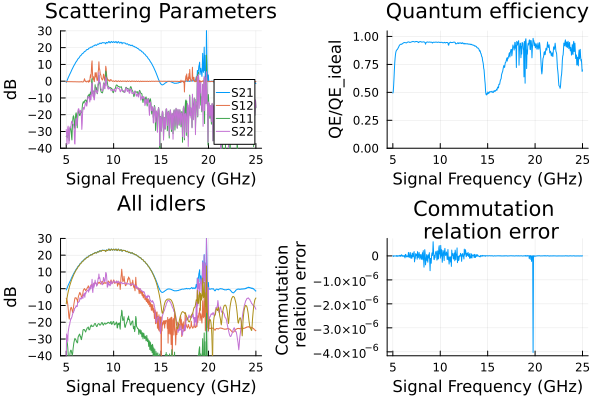

In [7]:
p1=plot(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S(
            outputmode=(0,),
            outputport=2,
            inputmode=(0,),
            inputport=1,
            freqindex=:),
    )),
    ylim=(-40,30),label="S21",
    xlabel="Signal Frequency (GHz)",
    legend=:bottomright,
    title="Scattering Parameters",
    ylabel="dB");

plot!(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S((0,),1,(0,),2,:))),
    label="S12",
    );

plot!(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S((0,),1,(0,),1,:))),
    label="S11",
    );

plot!(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S((0,),2,(0,),2,:))),
    label="S22",
    );

p2=plot(sol.linearized.w/(2*pi*1e9),
    sol.linearized.QE((0,),2,(0,),1,:)./sol.linearized.QEideal((0,),2,(0,),1,:),
    ylim=(0,1.05),
    title="Quantum efficiency",legend=false,
    ylabel="QE/QE_ideal",xlabel="Signal Frequency (GHz)");

p3=plot(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S(:,2,(0,),1,:)')),
    ylim=(-40,30),
    xlabel="Signal Frequency (GHz)",
    legend=false,
    title="All idlers",
    ylabel="dB");

p4=plot(sol.linearized.w/(2*pi*1e9),
    1 .- sol.linearized.CM((0,),2,:),
    legend=false,title="Commutation \n relation error",
    ylabel="Commutation \n relation error",xlabel="Signal Frequency (GHz)");

plot(p1, p2, p3, p4, layout = (2, 2))